In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [4]:
df = pd.read_csv("data-bank.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


In [6]:
df['Bankrupt?'].value_counts()

df['Bankrupt?'].value_counts(normalize=True)


Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64

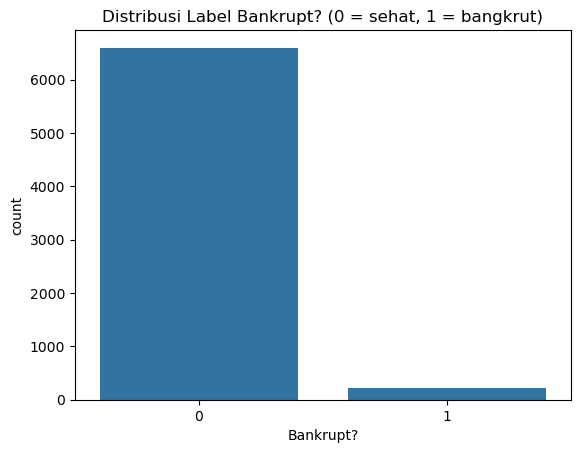

In [7]:
# Visualisasi distribusi label
sns.countplot(x='Bankrupt?', data=df)
plt.title('Distribusi Label Bankrupt? (0 = sehat, 1 = bangkrut)')
plt.show()


In [9]:
for i, c in enumerate(df.columns):
    print(i, "->", repr(c))


0 -> 'Bankrupt?'
1 -> ' ROA(C) before interest and depreciation before interest'
2 -> ' ROA(A) before interest and % after tax'
3 -> ' ROA(B) before interest and depreciation after tax'
4 -> ' Operating Gross Margin'
5 -> ' Realized Sales Gross Margin'
6 -> ' Operating Profit Rate'
7 -> ' Pre-tax net Interest Rate'
8 -> ' After-tax net Interest Rate'
9 -> ' Non-industry income and expenditure/revenue'
10 -> ' Continuous interest rate (after tax)'
11 -> ' Operating Expense Rate'
12 -> ' Research and development expense rate'
13 -> ' Cash flow rate'
14 -> ' Interest-bearing debt interest rate'
15 -> ' Tax rate (A)'
16 -> ' Net Value Per Share (B)'
17 -> ' Net Value Per Share (A)'
18 -> ' Net Value Per Share (C)'
19 -> ' Persistent EPS in the Last Four Seasons'
20 -> ' Cash Flow Per Share'
21 -> ' Revenue Per Share (Yuan ¥)'
22 -> ' Operating Profit Per Share (Yuan ¥)'
23 -> ' Per Share Net profit before tax (Yuan ¥)'
24 -> ' Realized Sales Gross Profit Growth Rate'
25 -> ' Operating Prof

In [10]:
df.columns = df.columns.str.strip()


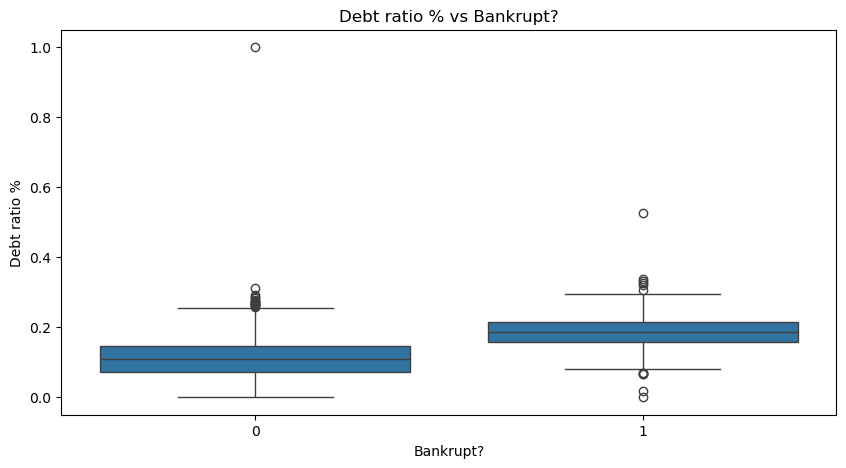

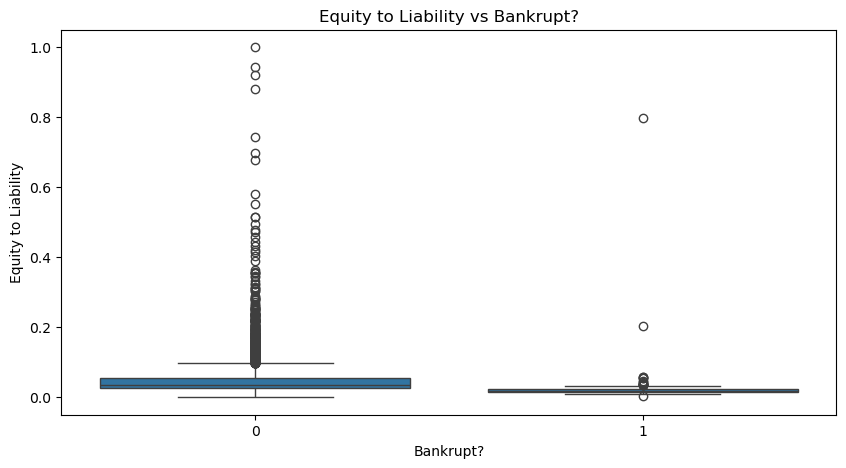

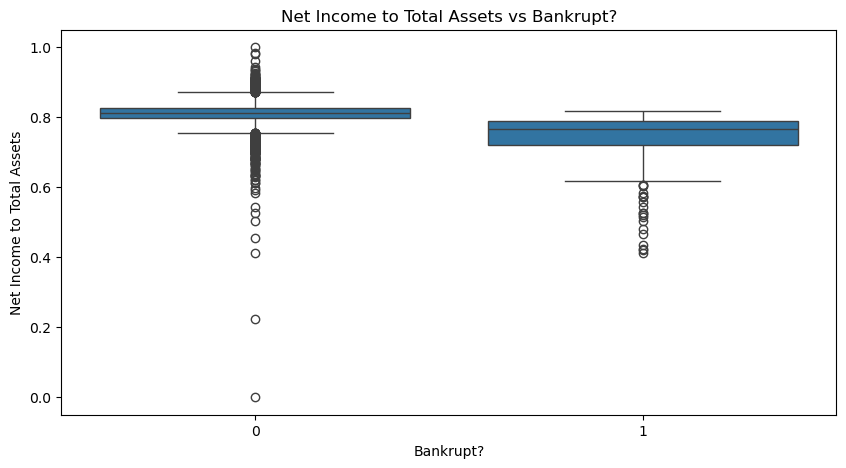

In [11]:
# ================================
# 4. EDA Singkat: contoh beberapa fitur penting
# ================================
plt.figure(figsize=(10,5))
sns.boxplot(x='Bankrupt?', y='Debt ratio %', data=df)
plt.title('Debt ratio % vs Bankrupt?')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Bankrupt?', y='Equity to Liability', data=df)
plt.title('Equity to Liability vs Bankrupt?')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Bankrupt?', y='Net Income to Total Assets', data=df)
plt.title('Net Income to Total Assets vs Bankrupt?')
plt.show()


In [12]:
# ================================
# 5. Data Preparation
# ================================
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

# Train-test split (stratify untuk menjaga perbandingan kelas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [38]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------

In [39]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 616.3 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 856.0 kB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 856.0 kB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 856.0 kB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 635.8 kB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 635.8 kB/s eta 0:00:01
   ------------------------------------ ---

In [40]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())

Before: Bankrupt?
0    5279
1     176
Name: count, dtype: int64
After: Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


=== XGBoost ===
              precision    recall  f1-score   support

           0     0.9811    0.9848    0.9830      1320
           1     0.4872    0.4318    0.4578        44

    accuracy                         0.9670      1364
   macro avg     0.7342    0.7083    0.7204      1364
weighted avg     0.9652    0.9670    0.9660      1364



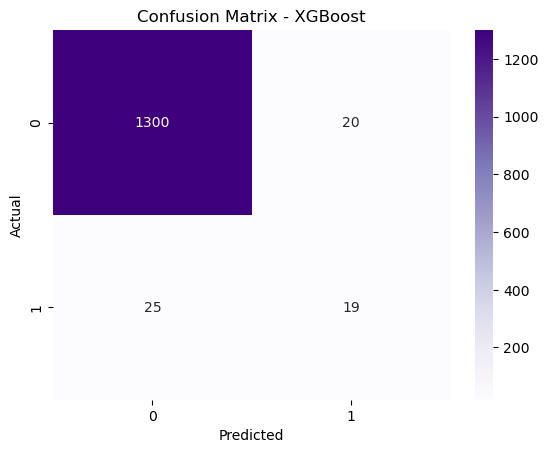

In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
#  XGBoost Model (Best Settings)
# ================================
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train with SMOTE-resampled data
xgb.fit(X_train_res, y_train_res)

# Predict (probabilities)
y_prob = xgb.predict_proba(X_test_scaled)[:,1]

# Threshold default 0.5
y_pred_xgb = (y_prob > 0.7).astype(int)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, digits=4))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score

# scorer khusus F1 untuk kelas 1 (bangkrut)
f1_pos_scorer = make_scorer(f1_score, pos_label=1)

param_dist = {
    "n_estimators":     [300, 500, 700, 900],
    "max_depth":        [3, 4, 5, 6, 8],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.2],
    "reg_alpha":        [0, 0.1, 0.5],
    "reg_lambda":       [0.5, 1.0, 2.0],
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,          # kalau kuat bisa dinaikkan 60–100
    scoring=f1_pos_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X_train_res, y_train_res)

print("Best params :", rs.best_params_)
print("Best CV F1 (class 1):", rs.best_score_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params : {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 900, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV F1 (class 1): 0.9852161844085946


In [53]:
best_xgb = rs.best_estimator_


In [56]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

best_t = None
best_f1 = -1
best_stats = None

thresholds = np.linspace(0.40, 0.85, 20)

print("t\tprecision_1\trecall_1\tf1_1")
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average=None, zero_division=0
    )
    p1, r1, f1_1 = p[1], r[1], f1[1]
    print(f"{t:.2f}\t{p1:.4f}\t\t{r1:.4f}\t{f1_1:.4f}")

    if f1_1 > best_f1:
        best_f1 = f1_1
        best_t = t
        best_stats = (p1, r1, f1_1)

print("\nBEST THRESHOLD:")
print(f"t={best_t:.2f}, precision_1={best_stats[0]:.4f}, recall_1={best_stats[1]:.4f}, f1_1={best_stats[2]:.4f}")


t	precision_1	recall_1	f1_1
0.40	0.4821		0.6136	0.5400
0.42	0.5000		0.6136	0.5510
0.45	0.5094		0.6136	0.5567
0.47	0.5094		0.6136	0.5567
0.49	0.5094		0.6136	0.5567
0.52	0.5094		0.6136	0.5567
0.54	0.5098		0.5909	0.5474
0.57	0.5098		0.5909	0.5474
0.59	0.5200		0.5909	0.5532
0.61	0.5532		0.5909	0.5714
0.64	0.5455		0.5455	0.5455
0.66	0.5750		0.5227	0.5476
0.68	0.5946		0.5000	0.5432
0.71	0.6286		0.5000	0.5570
0.73	0.6286		0.5000	0.5570
0.76	0.6364		0.4773	0.5455
0.78	0.6250		0.4545	0.5263
0.80	0.6207		0.4091	0.4932
0.83	0.5769		0.3409	0.4286
0.85	0.5600		0.3182	0.4058

BEST THRESHOLD:
t=0.61, precision_1=0.5532, recall_1=0.5909, f1_1=0.5714


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Probabilitas
y_prob_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

# threshold bisa pakai 0.7 dulu
thr = 0.7
y_pred_best = (y_prob_best > thr).astype(int)

print(f"=== XGBoost (best params, threshold={thr}) ===")
print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title(f"Confusion Matrix - XGBoost (t={thr})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


t	precision_1	recall_1	f1_1
0.40	0.4821		0.6136	0.5400
0.42	0.5000		0.6136	0.5510
0.45	0.5094		0.6136	0.5567
0.47	0.5094		0.6136	0.5567
0.49	0.5094		0.6136	0.5567
0.52	0.5094		0.6136	0.5567
0.54	0.5098		0.5909	0.5474
0.57	0.5098		0.5909	0.5474
0.59	0.5200		0.5909	0.5532
0.61	0.5532		0.5909	0.5714
0.64	0.5455		0.5455	0.5455
0.66	0.5750		0.5227	0.5476
0.68	0.5946		0.5000	0.5432
0.71	0.6286		0.5000	0.5570
0.73	0.6286		0.5000	0.5570
0.76	0.6364		0.4773	0.5455
0.78	0.6250		0.4545	0.5263
0.80	0.6207		0.4091	0.4932
0.83	0.5769		0.3409	0.4286
0.85	0.5600		0.3182	0.4058

BEST THRESHOLD:
t=0.61, precision_1=0.5532, recall_1=0.5909, f1_1=0.5714
